# LAB 1 for CS4243: Textures and Materials
## Notebook 2 — Material classification and defect localisation

> **Introduction.** This notebook runs Tasks A and B on real MVTec data. For
> Task B, normal models are fitted on training images, the pixel threshold is
> selected on public validation masks, and final results are reported on the
> held-out test split. Never tune a parameter after viewing test results.


## 1. Imports and reproducible configuration

Images are resized for a responsive walkthrough. Set `MAX_PER_GROUP = None`
when running the final experiment on every validation and test image.


In [1]:
import sys
from collections import Counter
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from texturelab.config import FeatureConfig, GaborConfig, NormalityConfig
from texturelab.data import load_mask, read_manifest
from texturelab.evaluation import evaluate_detection, evaluate_material
from texturelab.features import extract_local_features, feature_family_indices, global_pool
from texturelab.models import fit_material_classifier
from texturelab.normality import (
    fit_normal_model,
    predict_anomaly,
    select_mask_threshold,
)
from texturelab.supplied import load_image
from texturelab.visualize import plot_confusion, plot_reliability

MATERIALS = ("carpet", "grid", "leather", "tile", "wood")
IMAGE_SIZE = (64, 64)
MAX_PER_GROUP = 2  # Use None for the complete final evaluation.

feature_config = FeatureConfig(
    gabor=GaborConfig(
        frequencies=(0.10, 0.22),
        orientations=(0, np.pi / 2),
        kernel_size=11,
        pool_size=7,
    )
)
normal_config = NormalityConfig(
    image_percentile=99,
    threshold_percentile=99.5,
    score_pool_size=7,
    ignore_border=5,
)
mvtec = read_manifest(ROOT / "manifests" / "mvtec_textures.csv")

## 2. Audit the new split

The original labelled MVTec set is split deterministically within every
material/defect group: even-numbered files form validation and odd-numbered
files form test. This keeps every defect type in both partitions.


Counter({'train': 1266, 'validation': 267, 'test': 248})


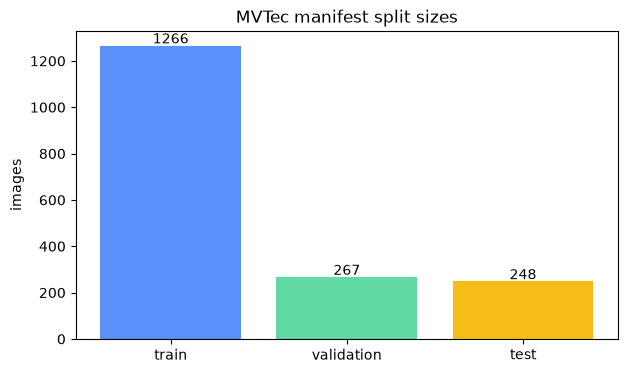

In [2]:
split_counts = Counter(record.split for record in mvtec)
print(split_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_counts.keys(), split_counts.values(), color=["#5b8ff9", "#61d9a5", "#f6bd16"])
ax.set(title="MVTec manifest split sizes", ylabel="images")
for index, value in enumerate(split_counts.values()):
    ax.text(index, value + 10, str(value), ha="center")
plt.show()

## 3. Task A — material classification

Task A uses only normal training images for fitting. The validation and test
sets below contain one good and one defective example per material so that the
walkthrough remains quick; use the complete sets for final reporting.


In [3]:
def first_records(split, material, condition, count=10):
    # Select a deterministic small subset for notebook demonstrations.
    selected = [
        record
        for record in mvtec
        if record.split == split
        and record.material == material
        and (
            (condition == "good" and record.defect_type == "good")
            or (condition == "defective" and record.defect_type != "good")
        )
    ]
    return selected if count is None else selected[:count]


train_records = sum(
    ([r for r in mvtec if r.split == "train" and r.material == material][:4]
     for material in MATERIALS),
    [],
)


validation_records = sum(
    (first_records("validation", material, "good")
     + first_records("validation", material, "defective")
     for material in MATERIALS),
    [],
)
test_records = sum(
    (first_records("test", material, "good")
     + first_records("test", material, "defective")
     for material in MATERIALS),
    [],
)


# train_records = sum(
#     ([r for r in mvtec if r.split == "train" and r.material == material]
#      for material in MATERIALS),
#     [],
# )

# validation_records = sum(
#     (first_records("validation", material, "good", 1000)
#      + first_records("validation", material, "defective", 1000)
#      for material in MATERIALS),
#     [],
# )
# test_records = sum(
#     (first_records("test", material, "good", 1000)
#      + first_records("test", material, "defective", 1000)
#      for material in MATERIALS),
#     [],
# )

default_statistics = ("mean", "std", "p90")
all_statistics =  ("mean", "std", "p10", "p50", "p90")
STATS = default_statistics

def image_descriptor(record, config=feature_config):
    image = load_image(record.path, IMAGE_SIZE)
    feature_map, _ = extract_local_features(image, config)
    return global_pool(feature_map, STATS)


x_train = np.stack([image_descriptor(record) for record in train_records])
x_validation = np.stack([image_descriptor(record) for record in validation_records])
x_test = np.stack([image_descriptor(record) for record in test_records])

material_model = fit_material_classifier(
    x_train,
    [record.material for record in train_records],
    C=5.0,
)

In [4]:
len(first_records("test", "wood", "good"))

9

In [5]:
x_test.shape

(99, 39)

### Visualise descriptor separation and test performance

PCA is used only for visualisation. The classifier itself receives the full
descriptor through a `StandardScaler` + `LogisticRegression` pipeline.


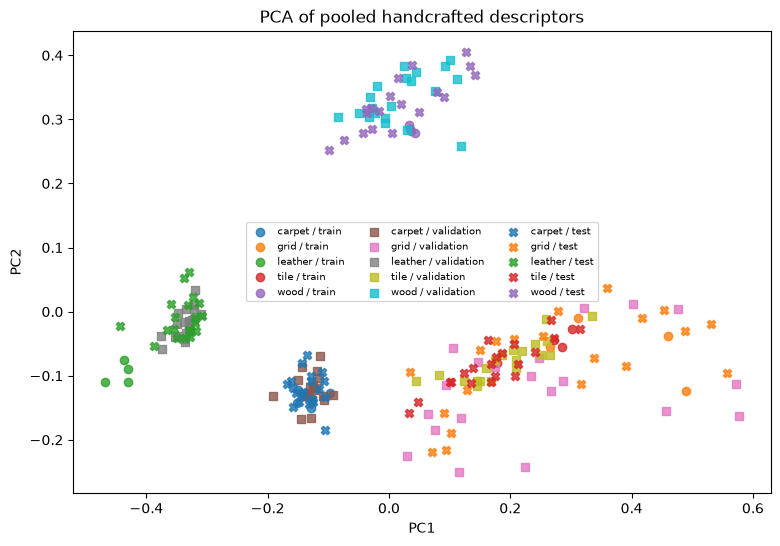

{'overall': {'count': 99, 'accuracy': 0.9494949494949495, 'macro_f1': 0.94917227475367, 'confusion_matrix': [[20, 0, 0, 0, 0], [2, 16, 0, 2, 0], [1, 0, 19, 0, 0], [0, 0, 0, 20, 0], [0, 0, 0, 0, 19]], 'ece': 0.04447725294816374}, 'good': {'count': 49, 'accuracy': 0.9183673469387755, 'macro_f1': 0.9136363636363637, 'confusion_matrix': [[10, 0, 0, 0, 0], [2, 6, 0, 2, 0], [0, 0, 10, 0, 0], [0, 0, 0, 10, 0], [0, 0, 0, 0, 9]], 'ece': 0.058649541772141774}, 'defective': {'count': 50, 'accuracy': 0.98, 'macro_f1': 0.9799498746867169, 'confusion_matrix': [[10, 0, 0, 0, 0], [0, 10, 0, 0, 0], [1, 0, 9, 0, 0], [0, 0, 0, 10, 0], [0, 0, 0, 0, 10]], 'ece': 0.06647644639015199}}


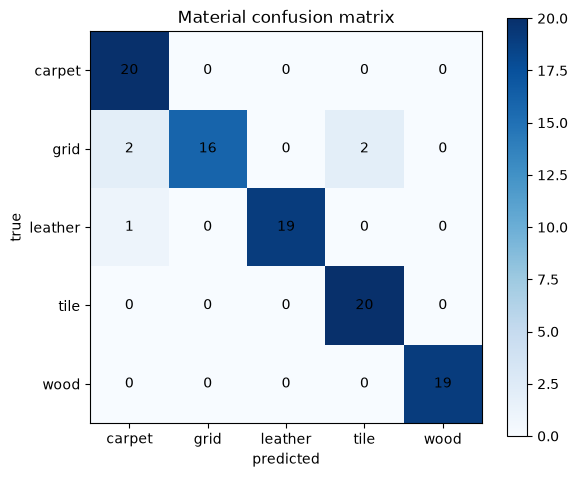

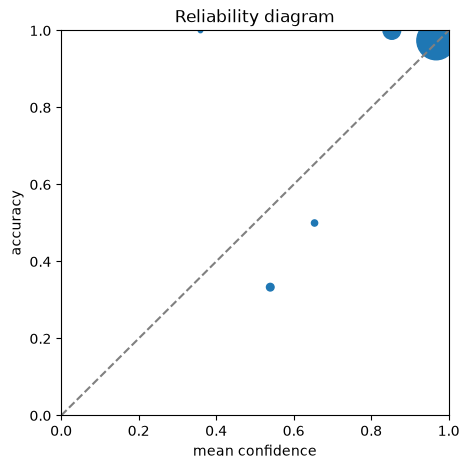

In [6]:
all_descriptors = np.vstack([x_train, x_validation, x_test])
projection = PCA(n_components=2).fit_transform(all_descriptors)
groups = (
    [(record, "train") for record in train_records]
    + [(record, "validation") for record in validation_records]
    + [(record, "test") for record in test_records]
)

fig, ax = plt.subplots(figsize=(9, 6))
markers = {"train": "o", "validation": "s", "test": "X"}
for split in markers:
    for material in MATERIALS:
        chosen = np.array(
            [record.material == material and group_split == split
             for record, group_split in groups]
        )
        ax.scatter(
            projection[chosen, 0],
            projection[chosen, 1],
            marker=markers[split],
            label=f"{material} / {split}",
            alpha=0.8,
        )
ax.set(title="PCA of pooled handcrafted descriptors", xlabel="PC1", ylabel="PC2")
ax.legend(ncol=3, fontsize=7)
plt.show()

test_probabilities = material_model.predict_proba(x_test)
task_a_report = evaluate_material(
    [record.material for record in test_records],
    test_probabilities,
    material_model.classes_,
    ["good" if record.defect_type == "good" else "defective"
     for record in test_records],
)
print(task_a_report)
plot_confusion(
    np.asarray(task_a_report["overall"]["confusion_matrix"]),
    material_model.classes_,
)
plot_reliability(
    np.asarray([record.material for record in test_records]),
    test_probabilities,
    material_model.classes_,
)
plt.show()

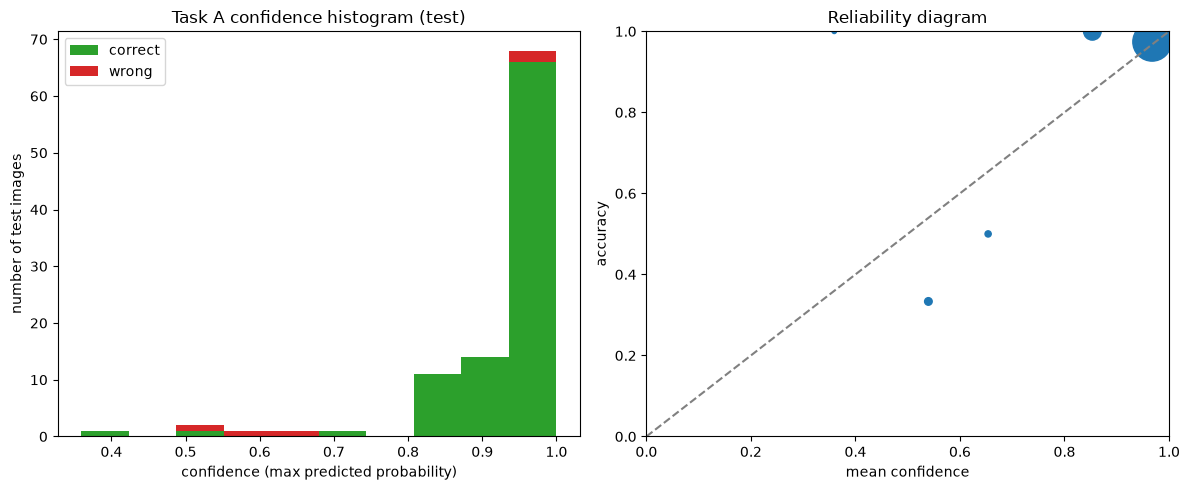

In [7]:
#[AI-CODE]
y_true = np.array([r.material for r in test_records])
confidence = test_probabilities.max(axis=1)
pred = material_model.classes_[test_probabilities.argmax(axis=1)]
correct = pred == y_true

fig, (ax_hist, ax_rel) = plt.subplots(1, 2, figsize=(12, 5))

# Left: confidence histogram
bins = np.linspace(confidence.min(), 1, 11)
ax_hist.hist([confidence[correct], confidence[~correct]], bins=bins,
             stacked=True, label=["correct", "wrong"], color=["tab:green", "tab:red"])
ax_hist.set(xlabel="confidence (max predicted probability)",
            ylabel="number of test images",
            title="Task A confidence histogram (test)")
ax_hist.legend()

# Right: reliability diagram
centres, acc, observed = [], [], []
for low in np.linspace(0, 1, 10, endpoint=False):
    mask = (confidence >= low) & (confidence < low + 0.1)
    if mask.any():
        centres.append(confidence[mask].mean())
        acc.append(correct[mask].mean())
        observed.append(mask.sum())
ax_rel.plot([0, 1], [0, 1], "--", color="gray")
ax_rel.scatter(centres, acc, s=np.asarray(observed) * 10)
ax_rel.set(xlim=(0, 1), ylim=(0, 1), xlabel="mean confidence",
           ylabel="accuracy", title="Reliability diagram")

fig.tight_layout()
plt.show()


5 errors (use 0 to 4), sorted from most to least confident


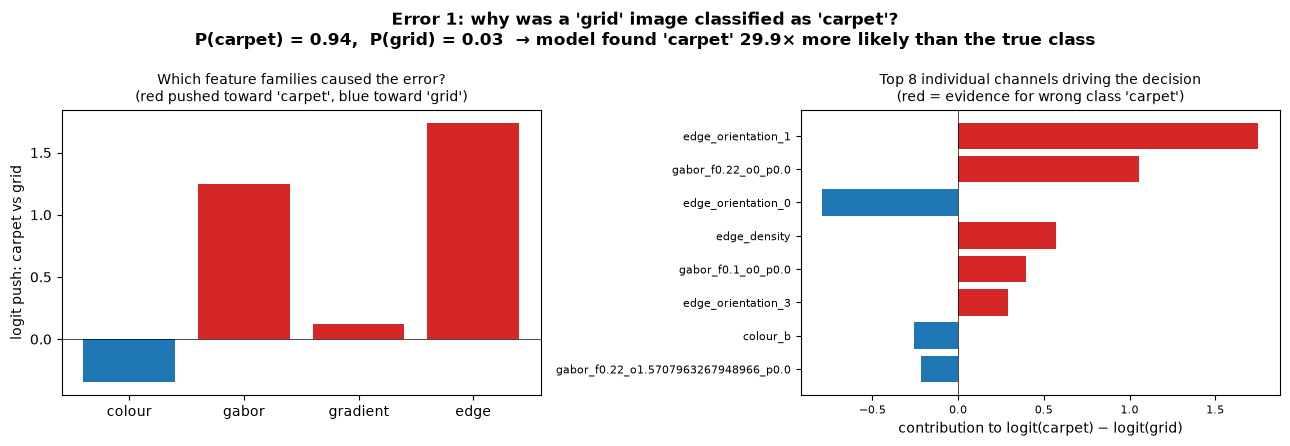

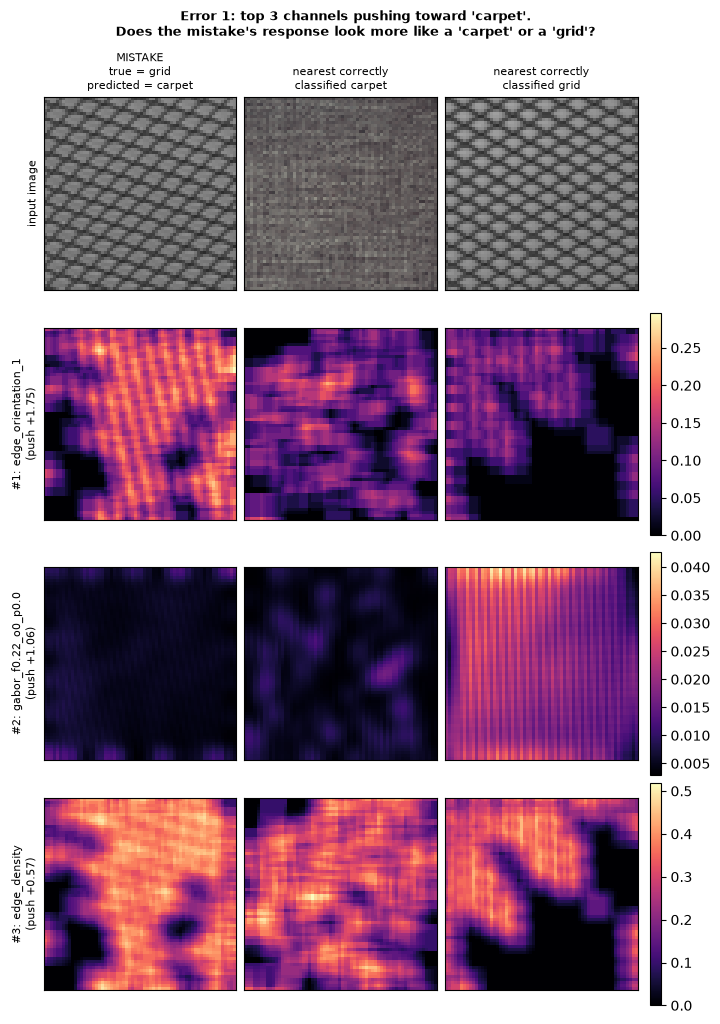

In [8]:
# [AI-CODE]
# Reuses from earlier cells: pred, confidence, x_test, test_probabilities, material_model, test_records, feature_config

true = np.array([r.material for r in test_records])
wrong = np.flatnonzero(pred != true)
wrong = wrong[np.argsort(-confidence[wrong])]  # most confident mistake first
z = material_model[:-1].transform(x_test)  # standardized descriptors fed to the LogisticRegression step

cache = []
for record in test_records:
    image = load_image(record.path, IMAGE_SIZE)
    feature_map, _ = extract_local_features(image, feature_config)
    cache.append((image, feature_map))

correct_mask = pred == true


def closest(i, pool):
    """Index within pool closest to example i in standardized descriptor space."""
    pool = np.asarray(pool)
    return pool[np.argmin(np.linalg.norm(z[pool] - z[i], axis=1))]


rows_for = {}
for i in wrong:
    predicted_pool = np.flatnonzero(correct_mask & (true == pred[i]))
    true_pool = np.flatnonzero(correct_mask & (true == true[i]))
    j_pred = closest(i, predicted_pool)
    j_true = closest(i, true_pool)
    rows_for[i] = [
        (i, f"MISTAKE\ntrue = {true[i]}\npredicted = {pred[i]}"),
        (j_pred, f"nearest correctly\nclassified {pred[i]}"),
        (j_true, f"nearest correctly\nclassified {true[i]}"),
    ]

lr = material_model[-1]                  # the LogisticRegression step
classes = list(lr.classes_)

_, names = extract_local_features(np.ones((1,1,3)), feature_config)          # just to get the names
D = len(names)
fam = feature_family_indices(names)


def channel_contributions(k):
    """Per-channel push toward the wrong class for error number k."""
    i = wrong[k]
    t, p = classes.index(true[i]), classes.index(pred[i])
    c = (lr.coef_[p] - lr.coef_[t]) * z[i]        # one value per descriptor entry
    c = c.reshape(len(STATS), D).sum(axis=0)      # add mean, std, p90 of each channel
    return c, i


def plot_contributions(k, top=8):
    """Plot 1: which families and channels pushed toward the wrong class."""
    c, i = channel_contributions(k)
    p_pred = test_probabilities[i, classes.index(pred[i])]
    p_true = test_probabilities[i, classes.index(true[i])]

    fam_sum = {f: c[idx].sum() for f, idx in fam.items() if idx}
    order = np.argsort(-np.abs(c))[:top][::-1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.bar(fam_sum.keys(), fam_sum.values(),
            color=["tab:red" if v > 0 else "tab:blue" for v in fam_sum.values()])
    ax1.axhline(0, color="k", lw=0.5)
    ax1.set_title(f"Which feature families caused the error?\n"
                  f"(red pushed toward '{pred[i]}', blue toward '{true[i]}')", fontsize=10)
    ax1.set_ylabel(f"logit push: {pred[i]} vs {true[i]}")

    ax2.barh([names[j] for j in order], c[order],
             color=["tab:red" if c[j] > 0 else "tab:blue" for j in order])
    ax2.axvline(0, color="k", lw=0.5)
    ax2.set_title(f"Top {top} individual channels driving the decision\n"
                  f"(red = evidence for wrong class '{pred[i]}')", fontsize=10)
    ax2.set_xlabel(f"contribution to logit({pred[i]}) − logit({true[i]})")
    ax2.tick_params(labelsize=8)

    fig.suptitle(f"Error {k}: why was a '{true[i]}' image classified as '{pred[i]}'?\n"
                 f"P({pred[i]}) = {p_pred:.2f},  P({true[i]}) = {p_true:.2f}  "
                 f"→ model found '{pred[i]}' {p_pred / p_true:.1f}× more likely than the true class",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()


# [AI-CODE]
def plot_channel(k, top=3, width=7):
    """Images on top, then one row per top-contributing channel map."""
    c, i = channel_contributions(k)
    channels = np.argsort(-c)[:top]       # channels pushing hardest toward the wrong class

    rows = rows_for[i]                    # mistake, nearest correct predicted, nearest correct true
    n = len(rows)
    fig, axes = plt.subplots(1 + top, n, figsize=(width, (1 + top) * width / n + 0.8),
                             squeeze=False, layout="constrained")

    for col, (idx, title) in enumerate(rows):
        axes[0, col].imshow(cache[idx][0])
        axes[0, col].set_title(title, fontsize=8)
    axes[0, 0].set_ylabel("input image", fontsize=8)

    for r, ch in enumerate(channels, start=1):
        maps = [cache[idx][1][..., ch] for idx, _ in rows]
        vmax = max(m.max() for m in maps)  # shared colour scale within the row
        for col, m in enumerate(maps):
            im = axes[r, col].imshow(m, cmap="magma", vmax=vmax)
        axes[r, 0].set_ylabel(f"#{r}: {names[ch]}\n(push {c[ch]:+.2f})", fontsize=8)
        fig.colorbar(im, ax=axes[r, :], fraction=0.03, pad=0.02)

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Error {k}: top {top} channels pushing toward '{pred[i]}'.\n"
                 f"Does the mistake's response look more like a '{pred[i]}' or a '{true[i]}'?",
                 fontsize=9, fontweight="bold")
    plt.show()


print(f"{len(wrong)} errors (use 0 to {len(wrong) - 1}), sorted from most to least confident")
k = 1                                  # which error (0 = most confident mistake)
top_k = 3                              # how many channel maps to show
plot_contributions(k)
plot_channel(k, top=top_k)


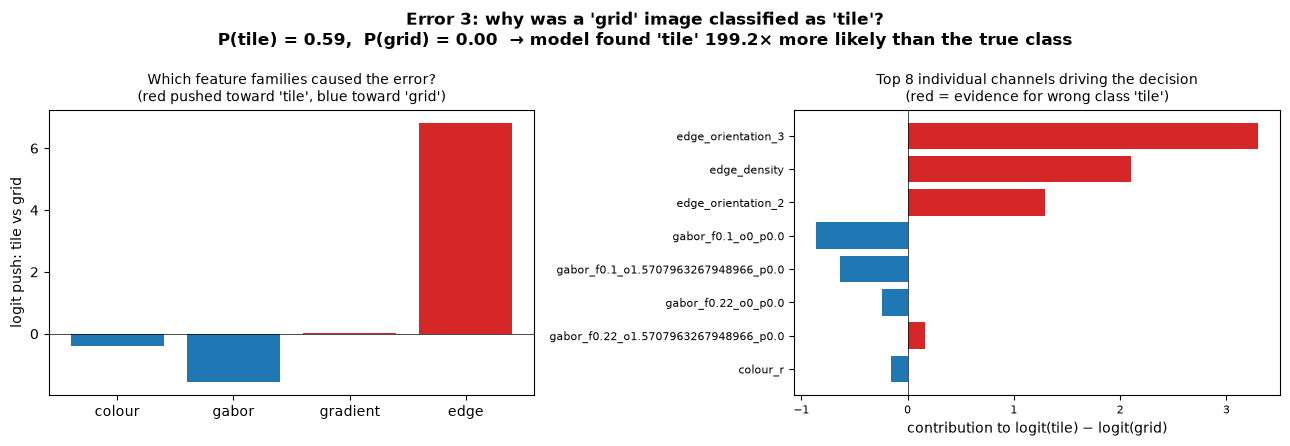

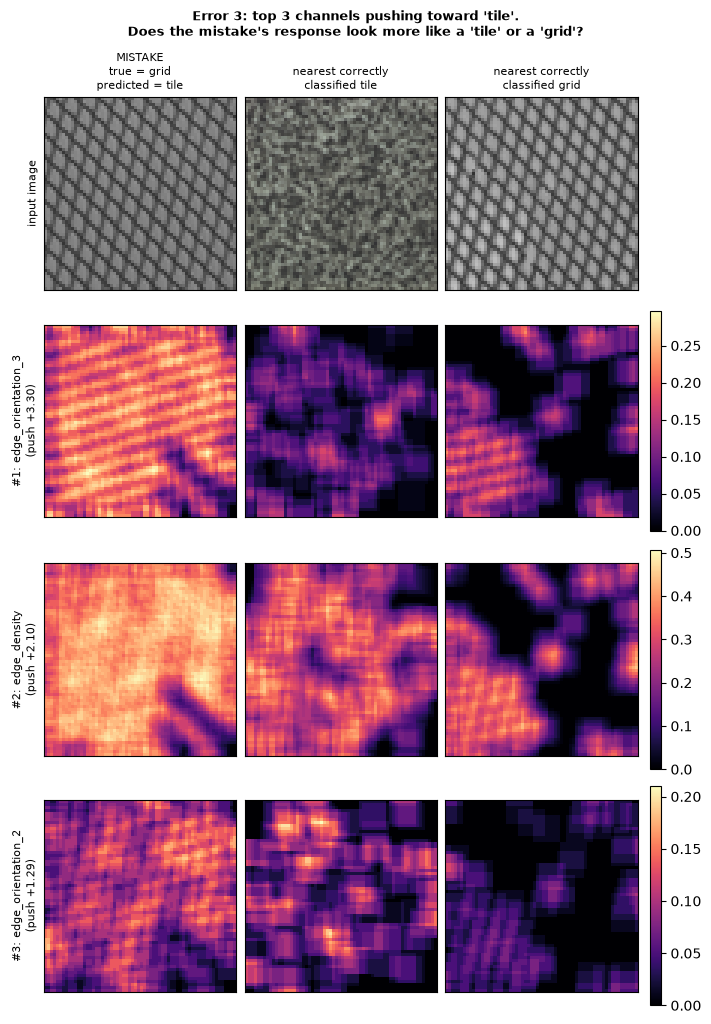

In [9]:
k = 3                              # which error (0 = most confident mistake)
top_k = 3                              # how many channel maps to show
plot_contributions(k)
plot_channel(k, top=top_k)


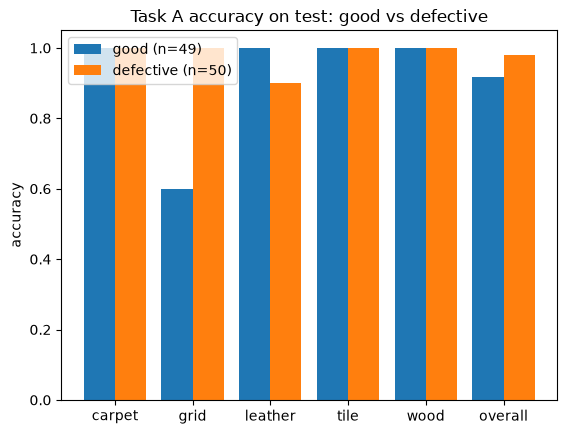

In [10]:
# [AI-CODE]
is_good = np.array([r.defect_type == "good" for r in test_records])
correct = pred == true
materials = list(MATERIALS)

acc_good = [correct[is_good & (true == m)].mean() for m in materials] + [correct[is_good].mean()]
acc_def = [correct[~is_good & (true == m)].mean() for m in materials] + [correct[~is_good].mean()]
labels = materials + ["overall"]

x = np.arange(len(labels))
plt.bar(x - 0.2, acc_good, 0.4, label=f"good (n={is_good.sum()})")
plt.bar(x + 0.2, acc_def, 0.4, label=f"defective (n={(~is_good).sum()})")
plt.xticks(x, labels)
plt.ylabel("accuracy")
plt.ylim(0, 1.05)
plt.title("Task A accuracy on test: good vs defective")
plt.legend()
plt.show()


5 errors (use 0 to 4), sorted from most to least confident


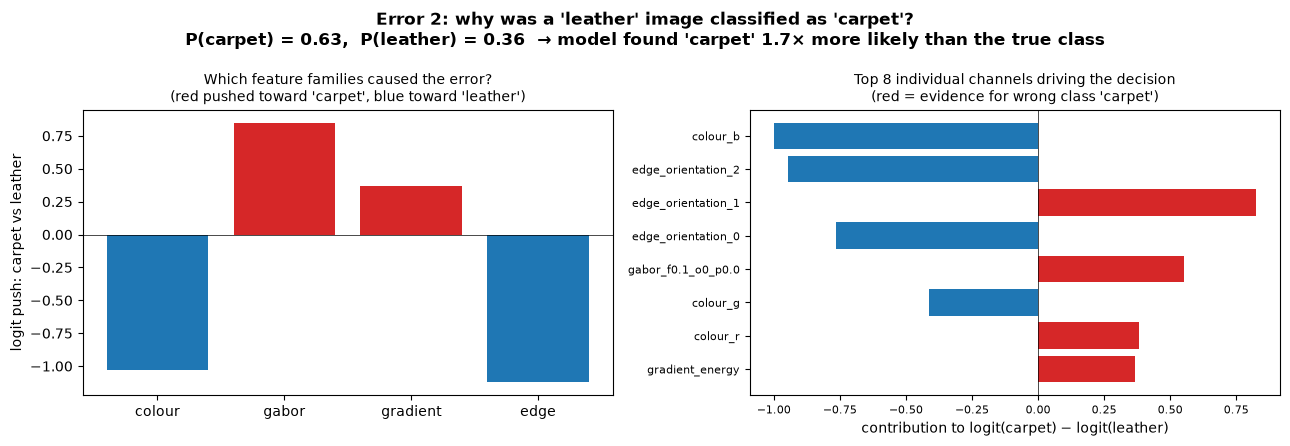

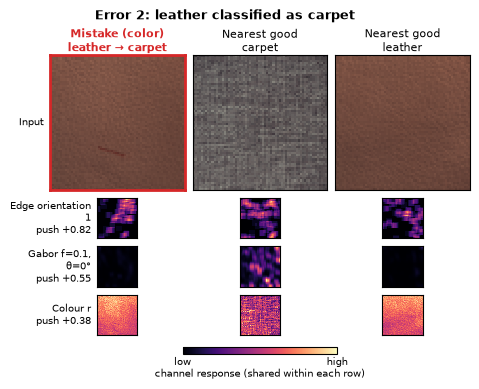

In [11]:
# [AI-CODE]
# Reuses from earlier cells: pred, confidence, x_test, test_probabilities, material_model, test_records, feature_config

true = np.array([r.material for r in test_records])
is_good = np.array([r.defect_type == "good" for r in test_records])
wrong = np.flatnonzero(pred != true)
wrong = wrong[np.argsort(-confidence[wrong])]  # most confident mistake first
z = material_model[:-1].transform(x_test)  # standardized descriptors fed to the LogisticRegression step

cache = []
for record in test_records:
    image = load_image(record.path, IMAGE_SIZE)
    feature_map, _ = extract_local_features(image, feature_config)
    cache.append((image, feature_map))

correct_mask = pred == true


def closest(i, pool):
    """Index within pool closest to example i in standardized descriptor space."""
    pool = np.asarray(pool)
    return pool[np.argmin(np.linalg.norm(z[pool] - z[i], axis=1))]


def reference_pool(material):
    """Correctly classified non-defective images of a material (any correct one if none are good)."""
    pool = np.flatnonzero(correct_mask & is_good & (true == material))
    if len(pool):
        return pool, "good"
    return np.flatnonzero(correct_mask & (true == material)), "any"


rows_for = {}
for i in wrong:
    predicted_pool, pred_kind = reference_pool(pred[i])
    true_pool, true_kind = reference_pool(true[i])
    j_pred = closest(i, predicted_pool)
    j_true = closest(i, true_pool)
    rows_for[i] = [
        (i, f"MISTAKE ({test_records[i].defect_type})\ntrue = {true[i]}\npredicted = {pred[i]}"),
        (j_pred, f"nearest {pred_kind}, correctly\nclassified {pred[i]}"),
        (j_true, f"nearest {true_kind}, correctly\nclassified {true[i]}"),
    ]

lr = material_model[-1]                  # the LogisticRegression step
classes = list(lr.classes_)

_, names = extract_local_features(np.ones((1,1,3)), feature_config)          # just to get the names
D = len(names)
fam = feature_family_indices(names)


def channel_contributions(k):
    """Per-channel push toward the wrong class for error number k."""
    i = wrong[k]
    t, p = classes.index(true[i]), classes.index(pred[i])
    c = (lr.coef_[p] - lr.coef_[t]) * z[i]        # one value per descriptor entry
    c = c.reshape(len(STATS), D).sum(axis=0)      # add mean, std, p90 of each channel
    return c, i


def plot_contributions(k, top=8):
    """Plot 1: which families and channels pushed toward the wrong class."""
    c, i = channel_contributions(k)
    p_pred = test_probabilities[i, classes.index(pred[i])]
    p_true = test_probabilities[i, classes.index(true[i])]

    fam_sum = {f: c[idx].sum() for f, idx in fam.items() if idx}
    order = np.argsort(-np.abs(c))[:top][::-1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.bar(fam_sum.keys(), fam_sum.values(),
            color=["tab:red" if v > 0 else "tab:blue" for v in fam_sum.values()])
    ax1.axhline(0, color="k", lw=0.5)
    ax1.set_title(f"Which feature families caused the error?\n"
                  f"(red pushed toward '{pred[i]}', blue toward '{true[i]}')", fontsize=10)
    ax1.set_ylabel(f"logit push: {pred[i]} vs {true[i]}")

    ax2.barh([names[j] for j in order], c[order],
             color=["tab:red" if c[j] > 0 else "tab:blue" for j in order])
    ax2.axvline(0, color="k", lw=0.5)
    ax2.set_title(f"Top {top} individual channels driving the decision\n"
                  f"(red = evidence for wrong class '{pred[i]}')", fontsize=10)
    ax2.set_xlabel(f"contribution to logit({pred[i]}) − logit({true[i]})")
    ax2.tick_params(labelsize=8)

    fig.suptitle(f"Error {k}: why was a '{true[i]}' image classified as '{pred[i]}'?\n"
                 f"P({pred[i]}) = {p_pred:.2f},  P({true[i]}) = {p_true:.2f}  "
                 f"→ model found '{pred[i]}' {p_pred / p_true:.1f}× more likely than the true class",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

# [AI-CODE]
def pretty_channel(name):
    """Readable two-line label for a channel, e.g. gabor_f0.25_o0.785_p0 -> 'Gabor f=0.25,\nθ=45°'."""
    if name.startswith("gabor_"):
        try:
            f, o, p = (part[1:] for part in name.split("_")[1:])
            return f"Gabor f={float(f):g},\nθ={np.degrees(float(o)):.0f}°" + (", odd" if float(p) else "")
        except ValueError:
            pass
    label = name.replace("_", " ").capitalize()
    return "\n".join(label.rsplit(" ", 1)) if len(label) > 13 else label   # wrap long labels once


def plot_channel(k, top=1, width=5.0, map_scale=0.6, save=None):
    """Three images on top; below, one compact row per channel pushing hardest toward the wrong class.

    Laid out explicitly in inches so text stays the same size whatever `width` is.
    """
    c, i = channel_contributions(k)
    channels = np.argsort(-c)[:top]
    cols = [idx for idx, _ in rows_for[i]]                 # mistake, nearest good pred, nearest good true
    headers = [f"Mistake ({test_records[i].defect_type})\n{true[i]} → {pred[i]}",
               f"Nearest good\n{pred[i]}",
               f"Nearest good\n{true[i]}"]

    label_w, gap, head_h, foot_h = 0.75, 0.08, 0.52, 0.42  # inches
    cell = (width - label_w - 0.05 - 2 * gap) / 3            # side of an input image
    side = map_scale * cell                                  # side of a feature map
    height = head_h + cell + top * (side + gap) + foot_h
    fig = plt.figure(figsize=(width, height))

    def add_ax(x, y_top, w, h):                              # inches, measured from the top-left corner
        return fig.add_axes([x / width, 1 - (y_top + h) / height, w / width, h / height])

    def row_label(y_mid, text):
        x = label_w + (cell - side) / 2 - 0.06               # use the margin left of the first map
        fig.text(x / width, 1 - y_mid / height, text, ha="right", va="center", fontsize=7)

    xs = [label_w + col * (cell + gap) for col in range(3)]

    y = head_h
    for col, (idx, header) in enumerate(zip(cols, headers)):
        ax = add_ax(xs[col], y, cell, cell)
        ax.imshow(cache[idx][0], interpolation="nearest")
        ax.set_title(header, fontsize=8, pad=3, color="tab:red" if col == 0 else "black",
                     fontweight="bold" if col == 0 else "normal")
        ax.set_xticks([]), ax.set_yticks([])
        if col == 0:
            for spine in ax.spines.values():
                spine.set(color="tab:red", linewidth=2)
    fig.text((label_w - 0.06) / width, 1 - (y + cell / 2) / height, "Input",
             ha="right", va="center", fontsize=7)

    y += cell + gap
    for ch in channels:
        maps = [cache[idx][1][..., ch] for idx in cols]
        lo, hi = min(m.min() for m in maps), max(m.max() for m in maps)   # shared scale per row
        for col, m in enumerate(maps):
            ax = add_ax(xs[col] + (cell - side) / 2, y, side, side)
            im = ax.imshow(m, cmap="magma", vmin=lo, vmax=hi, interpolation="nearest")
            ax.set_xticks([]), ax.set_yticks([])
        row_label(y + side / 2, f"{pretty_channel(names[ch])}\npush {c[ch]:+.2f}")
        y += side + gap

    cax = add_ax(xs[1] - 0.1, y + 0.04, cell + 0.2, 0.07)
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_ticks([lo, hi], labels=["low", "high"])
    cb.ax.tick_params(labelsize=7, length=0, pad=2)
    cb.set_label("channel response (shared within each row)", fontsize=7, labelpad=1)

    fig.suptitle(f"Error {k}: {true[i]} classified as {pred[i]}", fontsize=9, fontweight="bold",
                 y=1 - 0.06 / height, va="top")
    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()



print(f"{len(wrong)} errors (use 0 to {len(wrong) - 1}), sorted from most to least confident")
k = 2                                  # which error (0 = most confident mistake)
top_k = 3                       # how many channel maps to show
plot_contributions(k)
plot_channel(k, top=top_k, map_scale=0.3)


## 4. Task B — fit normal patch models

One model is fitted per material using normal training patches. Local averaging
of the standardized score suppresses isolated responses, and an outer border
is ignored because reflected filtering makes it unreliable.


In [12]:
normal_models = {}
for material in MATERIALS:
    records = [
        record
        for record in mvtec
        if record.split == "train" and record.material == material
    ]
    feature_maps = [
        extract_local_features(load_image(record.path, IMAGE_SIZE), feature_config)[0]
        for record in records
    ]
    normal_models[material] = fit_normal_model(feature_maps, normal_config)

## 5. Tune the mask threshold on validation only

This is the only stage allowed to inspect validation masks. The selected
threshold is copied into each material model and then frozen before test
evaluation.


In [13]:
def evaluation_subset(split):
    # Keep each defect type represented while limiting notebook runtime.
    chosen = []
    for material in MATERIALS:
        groups = sorted({
            record.defect_type
            for record in mvtec
            if record.split == split and record.material == material
        })
        for defect_type in groups:
            records = [
                record
                for record in mvtec
                if record.split == split
                and record.material == material
                and record.defect_type == defect_type
            ]
            chosen.extend(records if MAX_PER_GROUP is None else records[:MAX_PER_GROUP])
    return chosen


def score_dataset(records, config, models):
    score_maps, image_scores, provisional_masks, true_masks = [], [], [], []
    for record in records:
        image = load_image(record.path, IMAGE_SIZE)
        feature_map, _ = extract_local_features(image, config)
        score_map, image_score, predicted_mask = predict_anomaly(
            feature_map,
            models[record.material],
            normal_config,
        )
        true_mask = (
            load_mask(record.mask_path, IMAGE_SIZE)
            if record.mask_path
            else np.zeros(IMAGE_SIZE[::-1], dtype=bool)
        )
        score_maps.append(score_map)
        image_scores.append(image_score)
        provisional_masks.append(predicted_mask)
        true_masks.append(true_mask)
    return score_maps, image_scores, provisional_masks, true_masks


task_b_validation = evaluation_subset("validation")
validation_score_maps, validation_image_scores, _, validation_masks = score_dataset(
    task_b_validation,
    feature_config,
    normal_models,
)
threshold_score_maps = validation_score_maps
threshold_masks = validation_masks
if normal_config.ignore_border:
    border = normal_config.ignore_border
    threshold_score_maps = [
        score[border:-border, border:-border]
        for score in validation_score_maps
    ]
    threshold_masks = [
        mask[border:-border, border:-border]
        for mask in validation_masks
    ]
selected_threshold = select_mask_threshold(
    threshold_score_maps,
    threshold_masks,
)
for model in normal_models.values():
    model.threshold = selected_threshold

print(f"Validation-selected pixel threshold: {selected_threshold:.4f}")

Validation-selected pixel threshold: 3.5529


### Validation diagnostic — why the threshold plot looks difficult

This is intentionally not a clean two-cluster picture. Most pixels in a defective image are still normal background, while subtle defects may produce scores similar to ordinary texture variation. Resizing, local pooling, illumination changes, and the diagonal feature model further broaden both distributions. Consequently, the normal- and defect-pixel histograms overlap heavily and no vertical line can separate them perfectly.

> **Why the visual may look bad:** the logarithmic density axis exposes the long tails, and the enormous number of background pixels makes the normal distribution dominate. The selected line is an F1-optimal compromise on validation pixels—not evidence that the scores are well separated. Moving it left increases recall but creates many false positives; moving it right produces cleaner masks but misses weak or small defects. A single global threshold must also compromise across materials and defect types. Do not tune it again after viewing test results.


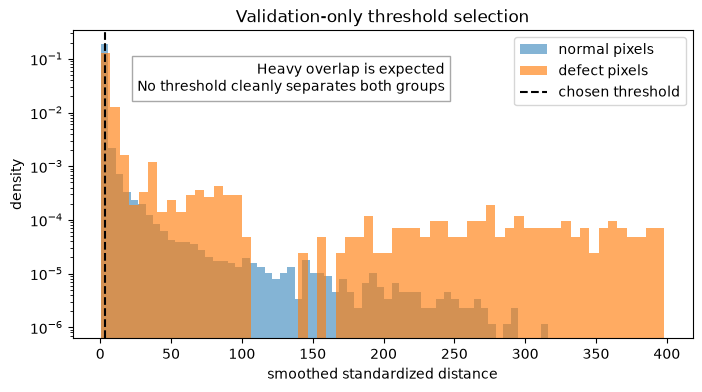

In [14]:
validation_pixels = np.concatenate([score.ravel() for score in threshold_score_maps])
validation_labels = np.concatenate([mask.ravel() for mask in threshold_masks])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    validation_pixels[~validation_labels],
    bins=60,
    density=True,
    alpha=0.55,
    label="normal pixels",
)
ax.hist(
    validation_pixels[validation_labels],
    bins=60,
    density=True,
    alpha=0.65,
    label="defect pixels",
)
ax.axvline(selected_threshold, color="black", linestyle="--", label="chosen threshold")
ax.set(xlabel="smoothed standardized distance", ylabel="density",
       title="Validation-only threshold selection")
ax.set_yscale("log")
ax.legend()
ax.text(
    0.6,
    0.9,
    "Heavy overlap is expected\nNo threshold cleanly separates both groups",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
)
plt.show()

## 6. Freeze choices and report test results

The following metrics are the Task B results. Do not return to the validation
stage after inspecting them.


{'image_auroc': 0.69, 'by_defect_type': {'color': {'f1': 0.38149100257069407, 'iou': 0.23570520965692504}, 'cut': {'f1': 0.1, 'iou': 0.05263157894736842}, 'good': {'f1': 0.0, 'iou': 0.0}, 'hole': {'f1': 0.24015748031496062, 'iou': 0.13646532438478748}, 'metal_contamination': {'f1': 0.0, 'iou': 0.0}, 'thread': {'f1': 0.0, 'iou': 0.0}, 'bent': {'f1': 0.0, 'iou': 0.0}, 'broken': {'f1': 0.0, 'iou': 0.0}, 'glue': {'f1': 0.2784471218206158, 'iou': 0.16174183514774496}, 'fold': {'f1': 0.12142857142857143, 'iou': 0.06463878326996197}, 'poke': {'f1': 0.03170227429359063, 'iou': 0.01610644257703081}, 'crack': {'f1': 0.0, 'iou': 0.0}, 'glue_strip': {'f1': 0.0, 'iou': 0.0}, 'gray_stroke': {'f1': 0.0, 'iou': 0.0}, 'oil': {'f1': 0.0, 'iou': 0.0}, 'rough': {'f1': 0.0, 'iou': 0.0}, 'combined': {'f1': 0.3116883116883117, 'iou': 0.18461538461538463}, 'liquid': {'f1': 0.649814126394052, 'iou': 0.4812775330396476}, 'scratch': {'f1': 0.0, 'iou': 0.0}}, 'pixel': {'f1': 0.17473514818291538, 'iou': 0.09573139

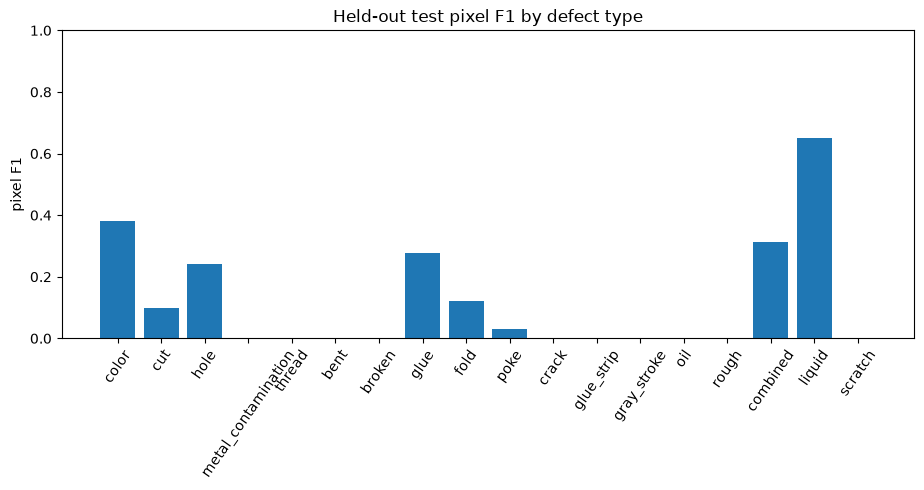

In [15]:
task_b_test = evaluation_subset("test")
test_score_maps, test_image_scores, test_predicted_masks, test_true_masks = score_dataset(
    task_b_test,
    feature_config,
    normal_models,
)
task_b_report = evaluate_detection(
    [record.defect_type != "good" for record in task_b_test],
    test_image_scores,
    test_true_masks,
    test_predicted_masks,
    [record.defect_type for record in task_b_test],
)
print(task_b_report)

# Summarise test behaviour by defect type.
defect_names = [name for name in task_b_report["by_defect_type"] if name != "good"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    defect_names,
    [task_b_report["by_defect_type"][name]["f1"] for name in defect_names],
)
ax.set(title="Held-out test pixel F1 by defect type", ylabel="pixel F1", ylim=(0, 1))
ax.tick_params(axis="x", rotation=55)
plt.show()

### Inspect an easier colour defect and its patch scores

Colour defects are often more visible to this compact descriptor than small
structural defects. This example is illustrative: many MVTec samples will have
substantially weaker localization and should be discussed honestly.


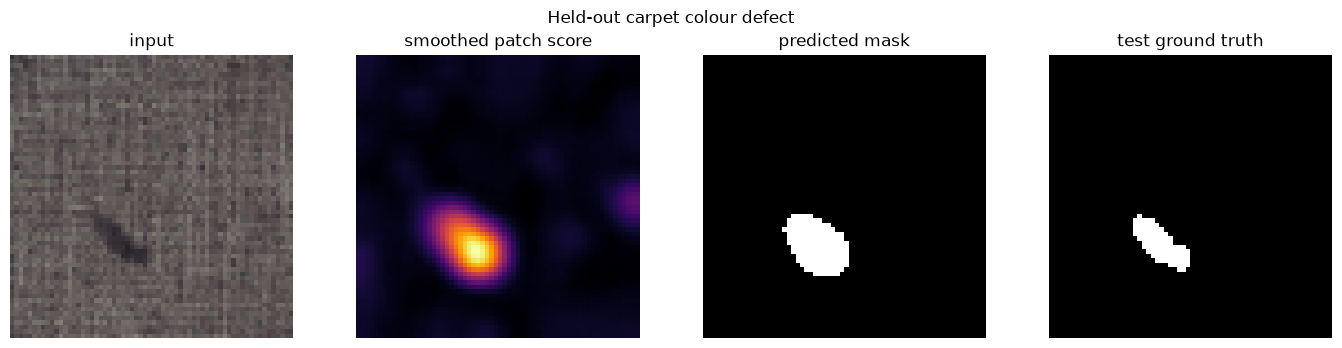

In [16]:
example_index = next(
    index
    for index, record in enumerate(task_b_test)
    if record.material == "carpet" and record.defect_type == "color"
)
example = task_b_test[example_index]
example_image = load_image(example.path, IMAGE_SIZE)
example_score = test_score_maps[example_index]
example_prediction = test_predicted_masks[example_index]
example_truth = test_true_masks[example_index]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
panels = [
    (example_image, "input", None),
    (example_score, "smoothed patch score", "inferno"),
    (example_prediction, "predicted mask", "gray"),
    (example_truth, "test ground truth", "gray"),
]
for ax, (data, title, cmap) in zip(axes, panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Held-out carpet colour defect")
fig.tight_layout()
plt.show()

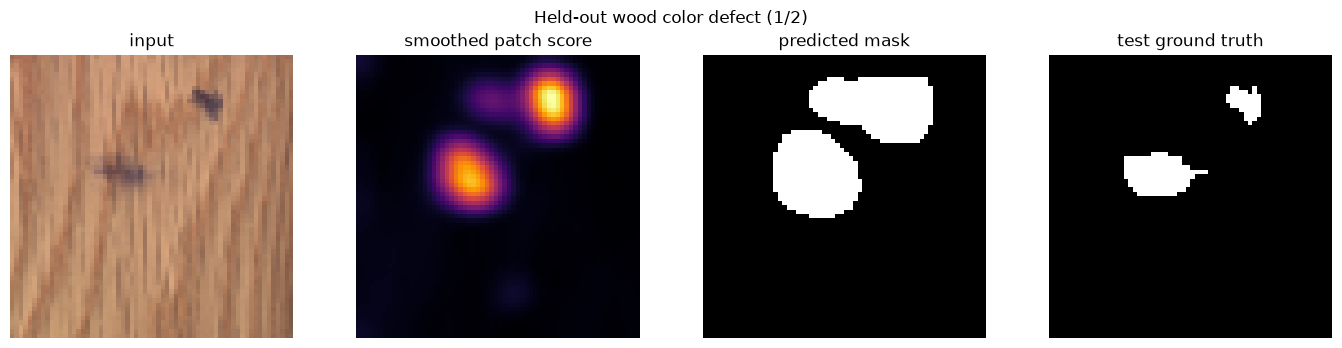

In [17]:
# [AI-CODE] — reusable helper to browse other test examples without touching the cell above
def show_defect_example(material, defect_type, number = 0):
    """Plot input/score/predicted-mask/ground-truth for one test example.

    `number` selects which matching test example to show (0 = first match).
    """
    matches = [
        i for i, record in enumerate(task_b_test)
        if record.material == material and record.defect_type == defect_type
    ]
    if not matches:
        raise ValueError(f"no test example for {material} / {defect_type}")
    if not 0 <= number < len(matches):
        raise IndexError(f"number must be in [0, {len(matches) - 1}] for {material} / {defect_type}")
    index = matches[number]
    image = load_image(task_b_test[index].path, IMAGE_SIZE)
    panels = [
        (image, "input", None),
        (test_score_maps[index], "smoothed patch score", "inferno"),
        (test_predicted_masks[index], "predicted mask", "gray"),
        (test_true_masks[index], "test ground truth", "gray"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, (data, title, cmap) in zip(axes, panels):
        ax.imshow(data, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"Held-out {material} {defect_type} defect ({number + 1}/{len(matches)})")
    fig.tight_layout()
    plt.show()



material, defect_type = "wood", "color"
show_defect_example(material, defect_type)

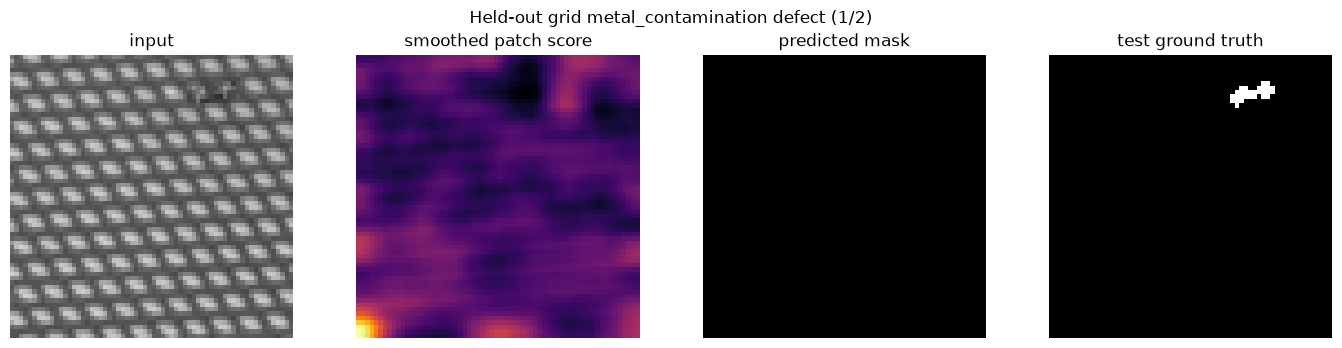

In [18]:
material, defect_type = "grid", "metal_contamination"
show_defect_example(material, defect_type)

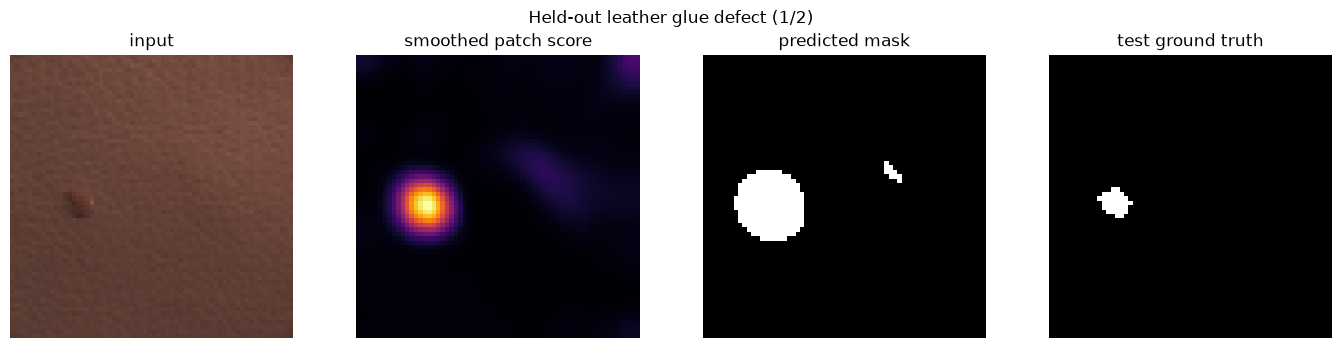

In [19]:
material, defect_type = "leather", "glue"
show_defect_example(material, defect_type)

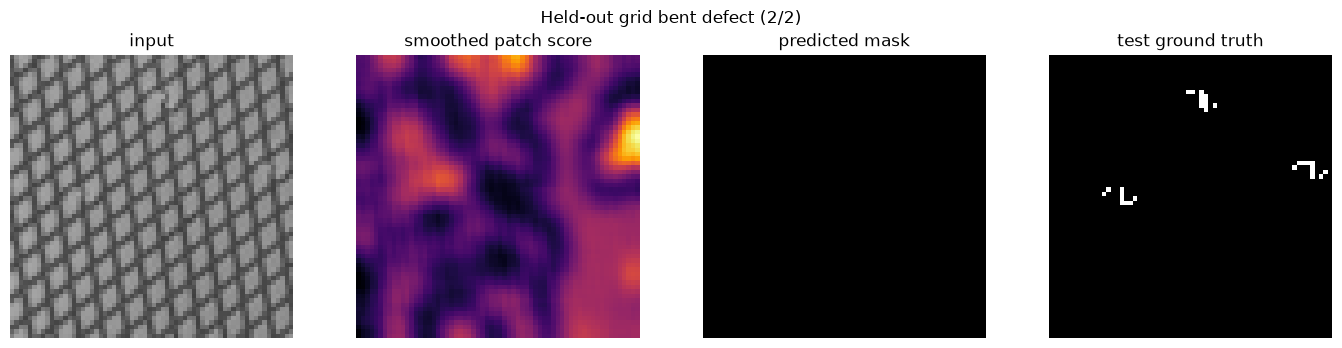

In [20]:
material, defect_type = "grid", "bent"
show_defect_example(material, defect_type,1)

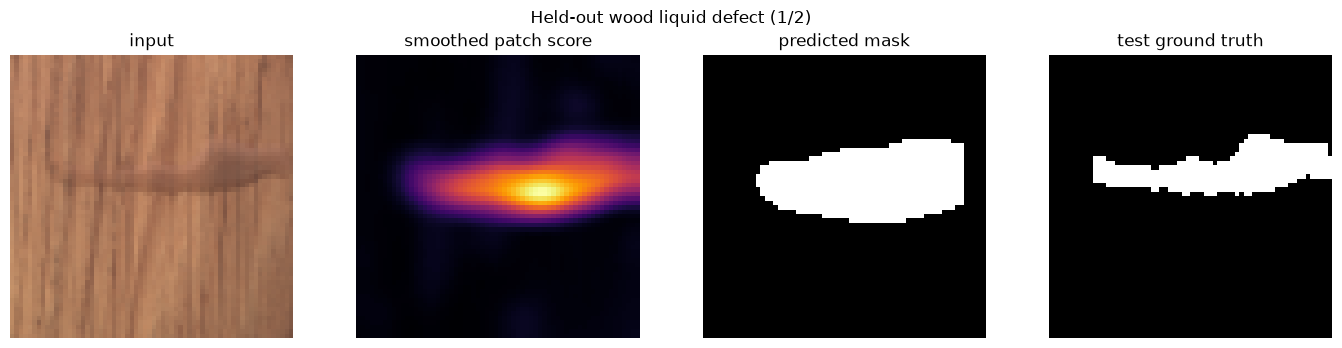

In [21]:
material, defect_type = "wood", "liquid"
show_defect_example(material, defect_type,0)

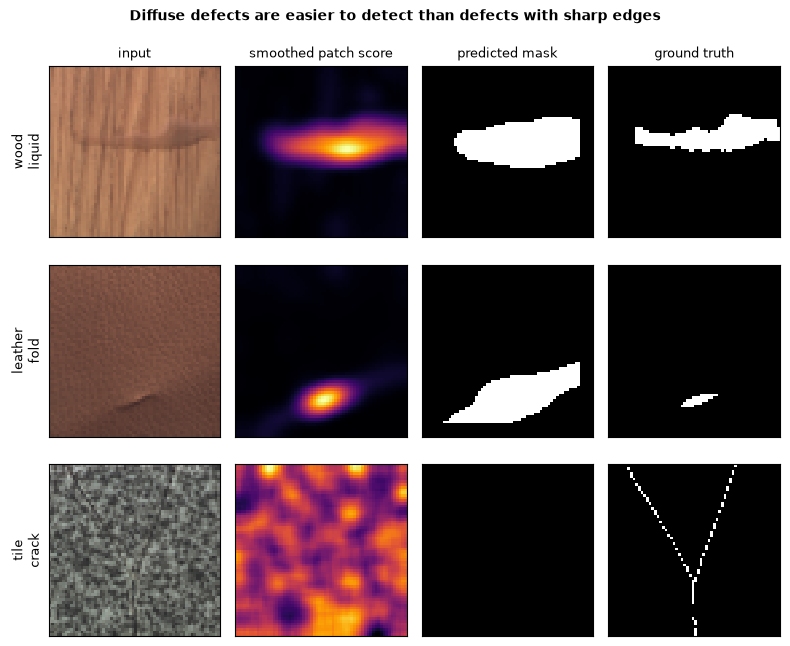

In [22]:
# [AI-CODE]
def show_defect_examples(examples, title, save=None):
    """One row per (material, defect_type): input / score / predicted mask / ground truth."""
    columns = ["input", "smoothed patch score", "predicted mask", "ground truth"]
    fig, axes = plt.subplots(len(examples), 4, figsize=(8, 2.1 * len(examples) + 0.4),
                             squeeze=False)
    for row, (material, defect_type) in enumerate(examples):
        index = next(
            i for i, record in enumerate(task_b_test)
            if record.material == material and record.defect_type == defect_type
        )
        panels = [
            (load_image(task_b_test[index].path, IMAGE_SIZE), None),
            (test_score_maps[index], "inferno"),
            (test_predicted_masks[index], "gray"),
            (test_true_masks[index], "gray"),
        ]
        for col, (data, cmap) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(data, cmap=cmap, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(columns[col], fontsize=9)
        axes[row, 0].set_ylabel(f"{material}\n{defect_type}", fontsize=9)
    fig.suptitle(title, fontsize=10, fontweight="bold")
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()


show_defect_examples(
    [("wood", "liquid"), ("leather", "fold"),("tile", "crack")],
    "Diffuse defects are easier to detect than defects with sharp edges",
)


## 7. Required feature-family ablation

Repeat the validation-threshold/test-report sequence for Gabor-only, edge-only,
and combined configurations. Do not share a threshold between branches unless
you justify doing so, and do not choose the winning branch from test results.


In [23]:
ablation_configs = {
    "Gabor only": FeatureConfig(
        include_colour=False,
        include_gradient=False,
        include_edges=False,
        gabor=feature_config.gabor,
    ),
    "Edge only": FeatureConfig(
        include_colour=False,
        include_gabor=False,
        gabor=feature_config.gabor,
    ),
    "Combined": feature_config,
}

print("Configurations prepared:", list(ablation_configs))

Configurations prepared: ['Gabor only', 'Edge only', 'Combined']


In [24]:
ablation_results = {}
ablation_models = {}  # [AI-CODE] kept for the map comparison below
for name, abl_config in ablation_configs.items():
    # fit a fresh normal model per material: the feature dimension changes with the config
    abl_models = {}
    for material in MATERIALS:
        records = [r for r in mvtec if r.split == "train" and r.material == material]
        feature_maps = [extract_local_features(load_image(r.path, IMAGE_SIZE), abl_config)[0] for r in records]
        abl_models[material] = fit_normal_model(feature_maps, normal_config)

    # select the threshold on validation only
    validation_score_maps, _, _, validation_masks = score_dataset(task_b_validation, abl_config, abl_models)
    border = normal_config.ignore_border
    threshold_score_maps = [score[border:-border, border:-border] for score in validation_score_maps]
    threshold_masks = [mask[border:-border, border:-border] for mask in validation_masks]
    threshold = select_mask_threshold(threshold_score_maps, threshold_masks)
    for model in abl_models.values():
        model.threshold = threshold
    ablation_models[name] = abl_models

    # freeze the threshold and report on held-out test
    _, test_image_scores, test_predicted_masks, test_true_masks = score_dataset(task_b_test, abl_config, abl_models)
    ablation_results[name] = evaluate_detection(
        [r.defect_type != "good" for r in task_b_test],
        test_image_scores,
        test_true_masks,
        test_predicted_masks,
        [r.defect_type for r in task_b_test],
    )
    print(f"{name}: threshold={threshold:.4f}  pixel F1={ablation_results[name]['pixel']['f1']:.4f}")

Gabor only: threshold=2.6954  pixel F1=0.1457
Edge only: threshold=3.5923  pixel F1=0.1635
Combined: threshold=3.5529  pixel F1=0.1747


### Comparing the branch maps

The three branches use different feature channels, but each produces one anomaly score per pixel, so their score maps and masks can be compared on the same images. Each map is divided by its branch's validation threshold so that the colour scales match.

defect type              Gabor only    Edge only     Combined
bent                         0.000        0.000        0.000 
broken                       0.000        0.000        0.000 
color                        0.217        0.568*       0.381 
combined                     0.264        0.180        0.312*
crack                        0.000        0.000        0.000 
cut                          0.077        0.107*       0.100 
fold                         0.086        0.147*       0.121 
glue                         0.182        0.295*       0.278 
glue_strip                   0.052*       0.000        0.000 
gray_stroke                  0.031*       0.000        0.000 
hole                         0.242*       0.190        0.240 
liquid                       0.596        0.572        0.650*
metal_contamination          0.000        0.000        0.000 
oil                          0.000        0.000        0.000 
poke                         0.018        0.043*       0.032 
rough   

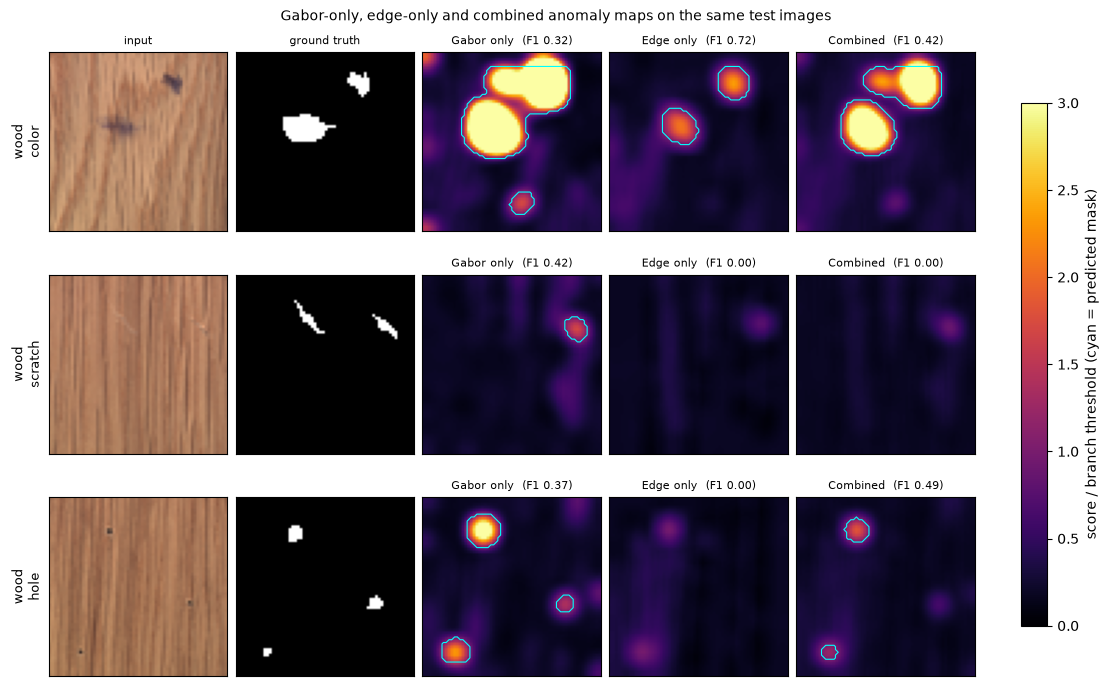

In [25]:
# [AI-CODE]
# Compare the three branches on the same test images. The feature maps differ between
# branches, but each one is turned into a single anomaly score per pixel, so the score
# maps and masks are aligned and comparable. Scores are divided by each branch's own
# validation threshold, so 1 means "at the threshold" for every branch.
from matplotlib.colors import Normalize

branches = list(ablation_configs)

# 1. Test pixel F1 per defect type for each branch (best branch marked with *).
print(f"{'defect type':<22}" + "".join(f"{b:>13}" for b in branches))
for defect in sorted(d for d in ablation_results["Combined"]["by_defect_type"] if d != "good"):
    scores = [ablation_results[b]["by_defect_type"][defect]["f1"] for b in branches]
    cells = [f"{s:.3f}" + ("*" if s == max(scores) and s > 0 else " ") for s in scores]
    print(f"{defect:<22}" + "".join(f"{c:>13}" for c in cells))


# 2. Score maps and masks of each branch on three contrasting test images.
def pixel_f1(pred, true):
    tp = (pred & true).sum()
    return 2 * tp / max(1, 2 * tp + (pred & ~true).sum() + (~pred & true).sum())


examples = [("wood", "color", 0), ("wood", "scratch", 1), ("wood", "hole", 1)]
fig, axes = plt.subplots(len(examples), 2 + len(branches), figsize=(11, 2.3 * len(examples)),
                         layout="constrained")
norm = Normalize(vmin=0, vmax=3)
for row, (material, defect_type, number) in enumerate(examples):
    record = [r for r in task_b_test if r.material == material and r.defect_type == defect_type][number]
    true_mask = load_mask(record.mask_path, IMAGE_SIZE)
    axes[row, 0].imshow(load_image(record.path, IMAGE_SIZE))
    axes[row, 1].imshow(true_mask, cmap="gray")
    axes[row, 0].set_ylabel(f"{material}\n{defect_type}", fontsize=9)
    for col, branch in enumerate(branches, start=2):
        model = ablation_models[branch][material]
        feature_map, _ = extract_local_features(load_image(record.path, IMAGE_SIZE), ablation_configs[branch])
        score, _, mask = predict_anomaly(feature_map, model, normal_config)
        image = axes[row, col].imshow(score / model.threshold, cmap="inferno", norm=norm)
        axes[row, col].contour(mask, levels=[0.5], colors="cyan", linewidths=0.8)
        axes[row, col].set_title(f"{branch}  (F1 {pixel_f1(mask, true_mask):.2f})", fontsize=8)
    if row == 0:
        axes[row, 0].set_title("input", fontsize=8)
        axes[row, 1].set_title("ground truth", fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(image, ax=axes, shrink=0.8, label="score / branch threshold (cyan = predicted mask)")
fig.suptitle("Gabor-only, edge-only and combined anomaly maps on the same test images", fontsize=10)
fig.savefig(ROOT / "student_files" / "report" / "ablation_maps.png", dpi=200, bbox_inches="tight")
plt.show()

In [26]:
# Save the frozen Task A/B artifacts for Notebook 4.
MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
task_ab_model_path = MODEL_DIR / "task_ab_models.joblib"
joblib.dump(
    {
        "material_classifier": material_model,
        "normal_models": normal_models,
        "feature_config": feature_config,
        "normality_config": normal_config,
        "materials": MATERIALS,
        "image_size": IMAGE_SIZE,
        "validation_selected_threshold": selected_threshold,
    },
    task_ab_model_path,
)
print("Saved frozen Task A/B models to:", task_ab_model_path)

Saved frozen Task A/B models to: /Users/caioartus/Desktop/Uni Stuff/Computer_Vision/labs/CS4243 Lab 1/code/outputs/models/task_ab_models.joblib


## 8. Full-data run

The sections above use small deterministic subsets (4 training images per material for Task A, 10 good and 10 defective test images per material, and `MAX_PER_GROUP` images per defect group for Task B). Here the same pipeline is repeated on the complete splits to see how much the reported numbers depend on the subset. No setting is tuned on test results, and the frozen models saved above are not modified.

images: train 1266, validation 267, test 248

Task A
run                             acc     F1  acc good  acc defect
20 train, 99 test (above)     0.949  0.949     0.918       0.980
20 train, full test           0.940  0.929     0.938       0.940
full train, full test         1.000  1.000     1.000       1.000

Task B
run                          threshold  pixel F1  pixel IoU   AUROC
2 per group (above)              3.553     0.175      0.096   0.690
full validation and test         3.402     0.168      0.092   0.662


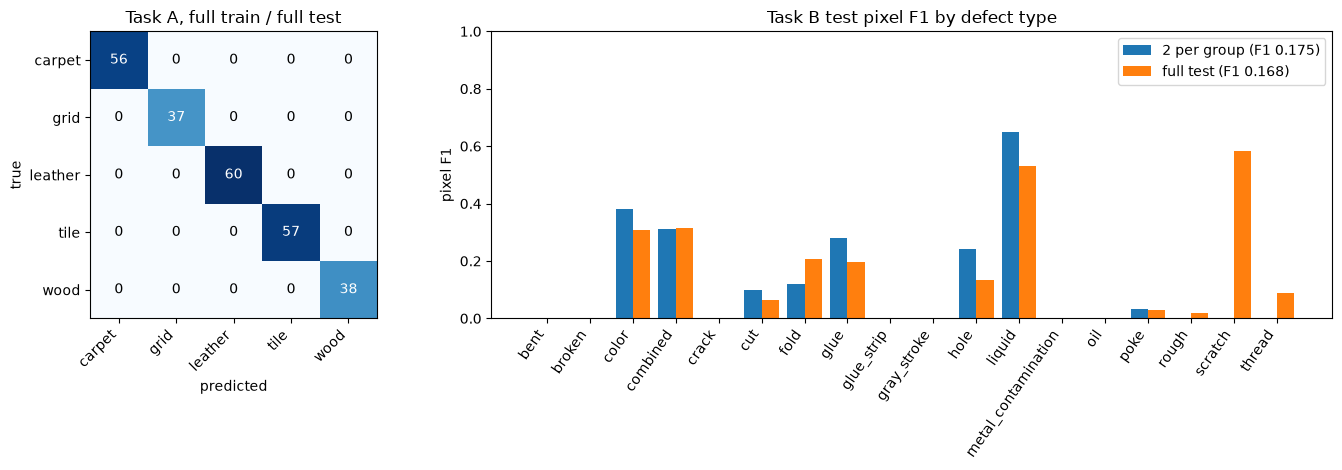

In [27]:
# [AI-CODE]
# Full-data run. Same features, statistics, classifier settings (C=5) and normal
# models as above; only the amount of data changes:
#   - Task A: all normal training images instead of the first 4 per material,
#     evaluated on the complete test split instead of 10 good + 10 defective per material.
#   - Task B: complete validation split for the threshold, complete test split for the
#     results, instead of MAX_PER_GROUP images per material/defect group.
# Nothing is saved: the frozen models used in Notebook 4 stay the ones fitted above.
import copy

full_train_records = [r for r in mvtec if r.split == "train"]
full_validation_records = [r for r in mvtec if r.split == "validation"]
full_test_records = [r for r in mvtec if r.split == "test"]
print(f"images: train {len(full_train_records)}, validation {len(full_validation_records)}, "
      f"test {len(full_test_records)}")

# --- Task A ---
x_train_full = np.stack([image_descriptor(r) for r in full_train_records])
x_test_full = np.stack([image_descriptor(r) for r in full_test_records])
material_model_full = fit_material_classifier(
    x_train_full, [r.material for r in full_train_records], C=5.0
)
y_test_full = [r.material for r in full_test_records]
conditions_full = ["good" if r.defect_type == "good" else "defective" for r in full_test_records]

task_a_runs = {
    "20 train, 99 test (above)": task_a_report,
    "20 train, full test": evaluate_material(
        y_test_full, material_model.predict_proba(x_test_full),
        material_model.classes_, conditions_full),
    "full train, full test": evaluate_material(
        y_test_full, material_model_full.predict_proba(x_test_full),
        material_model_full.classes_, conditions_full),
}
print("\nTask A")
print(f"{'run':<28}{'acc':>7}{'F1':>7}{'acc good':>10}{'acc defect':>12}")
for name, rep in task_a_runs.items():
    print(f"{name:<28}{rep['overall']['accuracy']:>7.3f}{rep['overall']['macro_f1']:>7.3f}"
          f"{rep['good']['accuracy']:>10.3f}{rep['defective']['accuracy']:>12.3f}")

# --- Task B ---
normal_models_full = copy.deepcopy(normal_models)
border = normal_config.ignore_border
val_maps, _, _, val_masks = score_dataset(full_validation_records, feature_config, normal_models_full)
threshold_full = select_mask_threshold(
    [s[border:-border, border:-border] for s in val_maps],
    [m[border:-border, border:-border] for m in val_masks],
)
for model in normal_models_full.values():
    model.threshold = threshold_full
_, test_scores_full, test_pred_full, test_true_full = score_dataset(
    full_test_records, feature_config, normal_models_full)
task_b_report_full = evaluate_detection(
    [r.defect_type != "good" for r in full_test_records],
    test_scores_full, test_true_full, test_pred_full,
    [r.defect_type for r in full_test_records],
)
print("\nTask B")
print(f"{'run':<28}{'threshold':>10}{'pixel F1':>10}{'pixel IoU':>11}{'AUROC':>8}")
for name, thr, rep in [("2 per group (above)", selected_threshold, task_b_report),
                       ("full validation and test", threshold_full, task_b_report_full)]:
    print(f"{name:<28}{thr:>10.3f}{rep['pixel']['f1']:>10.3f}{rep['pixel']['iou']:>11.3f}"
          f"{rep['image_auroc']:>8.3f}")

# --- Figure: full-data confusion matrix and per-defect F1, subset vs full ---
fig, (ax_cm, ax_f1) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 2.2]})
cm = np.asarray(task_a_runs["full train, full test"]["overall"]["confusion_matrix"])
ax_cm.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black")
classes = list(material_model_full.classes_)
ax_cm.set_xticks(range(len(classes)), classes, rotation=45, ha="right")
ax_cm.set_yticks(range(len(classes)), classes)
ax_cm.set(xlabel="predicted", ylabel="true", title="Task A, full train / full test")

defects = sorted(d for d in task_b_report_full["by_defect_type"] if d != "good")
f1_subset = [task_b_report["by_defect_type"][d]["f1"] for d in defects]
f1_full = [task_b_report_full["by_defect_type"][d]["f1"] for d in defects]
x = np.arange(len(defects))
ax_f1.bar(x - 0.2, f1_subset, 0.4, label=f"2 per group (F1 {task_b_report['pixel']['f1']:.3f})")
ax_f1.bar(x + 0.2, f1_full, 0.4, label=f"full test (F1 {task_b_report_full['pixel']['f1']:.3f})")
ax_f1.set_xticks(x, defects, rotation=55, ha="right")
ax_f1.set(ylabel="pixel F1", ylim=(0, 1), title="Task B test pixel F1 by defect type")
ax_f1.legend()
fig.tight_layout()
fig.savefig(ROOT / "student_files" / "report" / "full_data_comparison.png", dpi=200, bbox_inches="tight")
plt.show()